# Test Notebook

This notebook is a small, safe example for testing notebook analysis and editing workflows in Claude Code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Dataset

In [2]:
df = pd.DataFrame({
    "age": [25, 32, 40, 29, 35, np.nan, 45, 38],
    "salary": [500, 650, 800, 620, np.nan, 700, 900, 850],
    "department": ["HR", "IT", "IT", "HR", "Finance", "IT", "Finance", "HR"],
    "target": [0, 1, 1, 0, 1, 0, 1, 0]
})

df

,age,salary,department,target
0,25.0,500.0,HR,0
1,32.0,650.0,IT,1
2,40.0,800.0,IT,1
3,29.0,620.0,HR,0
4,35.0,NaN,Finance,1
5,NaN,700.0,IT,0
6,45.0,900.0,Finance,1
7,38.0,850.0,HR,0


## 2. Data Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         7 non-null      float64
 1   salary      7 non-null      float64
 2   department  8 non-null      str    
 3   target      8 non-null      int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 388.0 bytes


In [4]:
df.describe(include="all")

,age,salary,department,target
count,7.000000,7.000000,8,8.000000
unique,NaN,NaN,3,NaN
top,NaN,NaN,HR,NaN
freq,NaN,NaN,3,NaN
mean,34.857143,717.142857,NaN,0.500000
std,6.817345,141.033600,NaN,0.534522
min,25.000000,500.000000,NaN,0.000000
25%,30.500000,635.000000,NaN,0.000000
50%,35.000000,700.000000,NaN,0.500000
75%,39.000000,825.000000,NaN,1.000000


In [5]:
df.isnull().sum()

age           1
salary        1
department    0
target        0
dtype: int64

One missing value each in `age` and `salary` — ~12% of the dataset.

## 3. Distributions

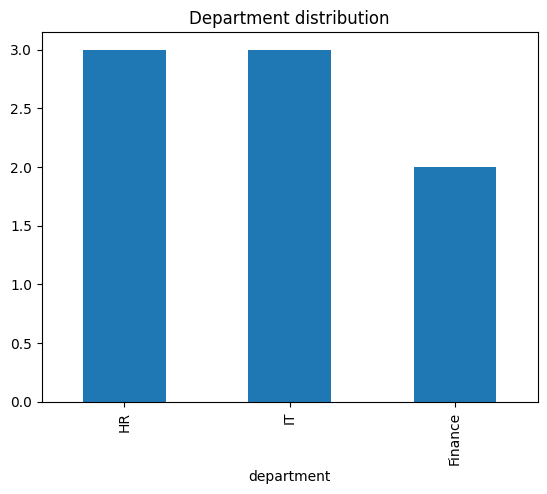

In [6]:
df["department"].value_counts().plot(kind="bar")
plt.title("Department distribution")
plt.show()

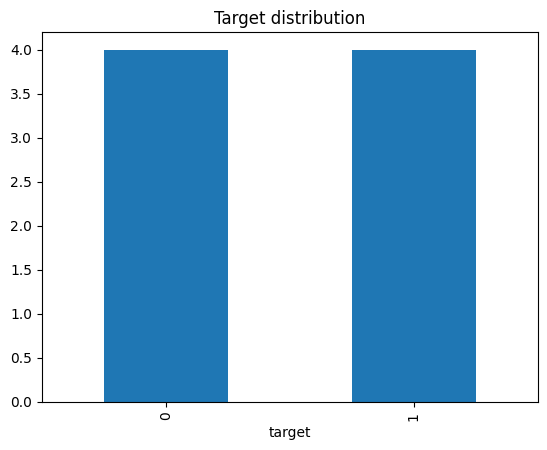

In [7]:
df["target"].value_counts().plot(kind="bar")
plt.title("Target distribution")
plt.show()

## 4. Correlations

In [8]:
corr = df[["age", "salary", "target"]].corr()
corr

,age,salary,target
age,1.000000,0.972170,0.574979
salary,0.972170,1.000000,0.439013
target,0.574979,0.439013,1.000000


Small sample (6–7 non-null pairs) — treat these as directional only.

## 5. Feature Engineering

In [9]:
df["salary_per_age"] = df["salary"] / df["age"]
df[["age", "salary", "salary_per_age"]]

,age,salary,salary_per_age
0,25.0,500.0,20.000000
1,32.0,650.0,20.312500
2,40.0,800.0,20.000000
3,29.0,620.0,21.379310
4,35.0,NaN,NaN
5,NaN,700.0,NaN
6,45.0,900.0,20.000000
7,38.0,850.0,22.368421


In [10]:
df["salary"] / df["age"]

0    20.000000
1    20.312500
2    20.000000
3    21.379310
4          NaN
5          NaN
6    20.000000
7    22.368421
dtype: float64

In [11]:
df["salary_centered"] = df["salary"] - df["salary"].mean()

## 6. Group Analysis

In [12]:
df.groupby("department")["salary"].mean()

department
Finance    900.000000
HR         656.666667
IT         716.666667
Name: salary, dtype: float64

2–3 rows per group — averages are indicative only.

The cell below references `unknown_column` (not in the dataset) — left intentionally to test error handling.

In [13]:
df["salary"].mean()

np.float64(717.1428571428571)